In [35]:
# -*- coding: utf-8 -*-

###################################################
# Ejemplo de uso de OpenPose a partir de OpenCV
# https://learnopencv.com/multi-person-pose-estimation-in-opencv-using-openpose/
# Descargar de dicha ruta los ficheros de pesos
##################################################
import cv2
import time
import numpy as np


In [36]:
# Descarga de los modelos preentrenados
!wget -O pose_deploy_linevec.prototxt https://github.com/nik1806/Human-Pose-Detection/raw/master/model/coco/pose_deploy_linevec.prototxt

--2025-05-09 00:12:54--  https://github.com/nik1806/Human-Pose-Detection/raw/master/model/coco/pose_deploy_linevec.prototxt
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/nik1806/Human-Pose-Detection/master/model/coco/pose_deploy_linevec.prototxt [following]
--2025-05-09 00:12:54--  https://raw.githubusercontent.com/nik1806/Human-Pose-Detection/master/model/coco/pose_deploy_linevec.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46371 (45K) [text/plain]
Saving to: ‘pose_deploy_linevec.prototxt’

pose_deploy_linevec 100%[===================>]  45.28K  --.-KB/s    in 0.007s  

2025-05-09

In [37]:
!wget -O pose_iter_440000.caffemodel https://github.com/nik1806/Human-Pose-Detection/raw/master/model/coco/pose_iter_440000.caffemodel

--2025-05-09 00:13:10--  https://github.com/nik1806/Human-Pose-Detection/raw/master/model/coco/pose_iter_440000.caffemodel
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/nik1806/Human-Pose-Detection/master/model/coco/pose_iter_440000.caffemodel [following]
--2025-05-09 00:13:10--  https://media.githubusercontent.com/media/nik1806/Human-Pose-Detection/master/model/coco/pose_iter_440000.caffemodel
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 209274056 (200M) [application/octet-stream]
Saving to: ‘pose_iter_440000.caffemodel’

pose_iter_440000.ca 100%[===================>] 199.5

In [38]:
# Descarga imagen
!wget -O DSC_0154.JPG https://github.com/palasatenea66/DATASETS/raw/main/DSC_0154.JPG

--2025-05-09 00:13:29--  https://github.com/palasatenea66/DATASETS/raw/main/DSC_0154.JPG
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/palasatenea66/DATASETS/main/DSC_0154.JPG [following]
--2025-05-09 00:13:29--  https://raw.githubusercontent.com/palasatenea66/DATASETS/main/DSC_0154.JPG
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9436435 (9.0M) [image/jpeg]
Saving to: ‘DSC_0154.JPG’

DSC_0154.JPG        100%[===================>]   9.00M  --.-KB/s    in 0.06s   

2025-05-09 00:13:30 (154 MB/s) - ‘DSC_0154.JPG’ saved [9436435/9436435]



In [39]:
!ls

DSC_0154.JPG				open_pose_resultado_final.jpg
openpose_confianza_cuello.jpg		pose_deploy_linevec.prototxt
openpose_paf_cuello_hombro_derecho.jpg	pose_iter_440000.caffemodel
openpose_puntos_esqueleto.jpg		sample_data


In [40]:
# Dispositivo a utilizar (cpu/gpu).
# OpenCV requiere compilación para uso de GPU si se quiere utilizar CUDA.
device = "cpu"

# Imagen a procesar
image1 = cv2.imread("DSC_0154.JPG")

In [41]:
# Descripción de la red neuronal a utilizar (formato CAFFE)
protoFile = "pose_deploy_linevec.prototxt"
# Pesos del modelo preentrenado
weightsFile = "pose_iter_440000.caffemodel"


In [ ]:
# Número total de puntos (articulaciones) a detectar en el cuerpo humano
nPoints = 18

# Nombres de las articulaciones según la convención del modelo COCO
keypointsMapping = [
    'Nose', 'Neck', 'R-Sho', 'R-Elb', 'R-Wr',
    'L-Sho', 'L-Elb', 'L-Wr', 'R-Hip', 'R-Knee', 'R-Ank',
    'L-Hip', 'L-Knee', 'L-Ank', 'R-Eye', 'L-Eye', 'R-Ear', 'L-Ear'
]

# Pares de articulaciones que se conectan entre sí para formar el esqueleto
# Cada sublista representa una línea (por ejemplo, [1,2] conecta el cuello con el hombro derecho)
POSE_PAIRS = [
    [1,2], [1,5], [2,3], [3,4], [5,6], [6,7],
    [1,8], [8,9], [9,10], [1,11], [11,12], [12,13],
    [1,0], [0,14], [14,16], [0,15], [15,17],
    [2,17], [5,16]
]

# Índices de los mapas de afinidad de partes (PAFs) que corresponden a cada par de articulaciones.
# Los PAFs son vectores que indican la conexión entre dos puntos clave (dirección y fuerza).
# Por ejemplo, el par [1,2] (cuello y hombro derecho) usa los mapas (31,32) de la salida de la red.
mapIdx = [
    [31,32], [39,40], [33,34], [35,36], [41,42], [43,44],
    [19,20], [21,22], [23,24], [25,26], [27,28], [29,30],
    [47,48], [49,50], [53,54], [51,52], [55,56],
    [37,38], [45,46]
]


In [ ]:
# ========================================
# FUNCIONES PRINCIPALES DE OPENPOSE
# ========================================

# ------------------------------------------------------------
# A partir de los mapas de confianza (probMap) detecta los máximos locales
# para determinar la posición exacta de cada articulación.
# ------------------------------------------------------------
def getKeypoints(probMap, threshold=0.1):

    # 1️⃣ Suaviza el mapa de probabilidad para eliminar ruido
    mapSmooth = cv2.GaussianBlur(probMap, (3,3), 0, 0)

    # 2️⃣ Crea una máscara binaria donde los valores mayores al umbral son 1 (posibles puntos clave)
    mapMask = np.uint8(mapSmooth > threshold)
    keypoints = []

    # 3️⃣ Busca los contornos (regiones conectadas) en la máscara
    contours, _ = cv2.findContours(mapMask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # 4️⃣ Para cada contorno, obtiene el punto con máxima probabilidad (máximo local)
    for cnt in contours:
        blobMask = np.zeros(mapMask.shape)
        blobMask = cv2.fillConvexPoly(blobMask, cnt, 1)
        maskedProbMap = mapSmooth * blobMask
        _, maxVal, _, maxLoc = cv2.minMaxLoc(maskedProbMap)
        # Guarda coordenadas (x, y) y el valor de confianza
        keypoints.append(maxLoc + (probMap[maxLoc[1], maxLoc[0]],))

    return keypoints


# ------------------------------------------------------------
# Busca conexiones válidas entre pares de articulaciones
# usando los mapas de afinidad de partes (PAF).
# ------------------------------------------------------------
def getValidPairs(output):
    valid_pairs = []    # pares válidos
    invalid_pairs = []  # pares inválidos
    n_interp_samples = 10  # puntos de muestreo entre articulaciones
    paf_score_th = 0.1     # umbral mínimo de score PAF
    conf_th = 0.7          # umbral de confianza

    # Recorre todos los pares de articulaciones definidos en POSE_PAIRS
    for k in range(len(mapIdx)):
        # Cada POSE_PAIR (A, B) tiene dos mapas PAF correspondientes (pafA, pafB)
        pafA = output[0, mapIdx[k][0], :, :]
        pafB = output[0, mapIdx[k][1], :, :]

        # Redimensiona los mapas PAF al tamaño del frame original
        pafA = cv2.resize(pafA, (frameWidth, frameHeight))
        pafB = cv2.resize(pafB, (frameWidth, frameHeight))

        # Obtiene los puntos clave detectados para las articulaciones A y B
        candA = detected_keypoints[POSE_PAIRS[k][0]]
        candB = detected_keypoints[POSE_PAIRS[k][1]]
        nA = len(candA)
        nB = len(candB)

        # Si ambos puntos (A y B) existen, busca la conexión entre ellos
        if nA != 0 and nB != 0:
            valid_pair = np.zeros((0, 3))  # almacena pares válidos (idA, idB, score)
            for i in range(nA):
                max_j = -1
                maxScore = -1
                found = 0
                for j in range(nB):
                    # Vector entre las articulaciones A y B
                    d_ij = np.subtract(candB[j][:2], candA[i][:2])
                    norm = np.linalg.norm(d_ij)
                    if norm:
                        d_ij = d_ij / norm
                    else:
                        continue

                    # Coordenadas interpoladas entre A y B (puntos intermedios)
                    interp_coord = list(zip(
                        np.linspace(candA[i][0], candB[j][0], num=n_interp_samples),
                        np.linspace(candA[i][1], candB[j][1], num=n_interp_samples)
                    ))

                    # Obtiene los valores de los PAF en esos puntos intermedios
                    paf_interp = []
                    for k in range(len(interp_coord)):
                        paf_interp.append([
                            pafA[int(round(interp_coord[k][1])), int(round(interp_coord[k][0]))],
                            pafB[int(round(interp_coord[k][1])), int(round(interp_coord[k][0]))]
                        ])

                    # Calcula qué tan alineado está el vector de articulaciones con el PAF
                    paf_scores = np.dot(paf_interp, d_ij)
                    avg_paf_score = sum(paf_scores) / len(paf_scores)

                    # Si la mayoría de los puntos están alineados con el PAF → conexión válida
                    if (len(np.where(paf_scores > paf_score_th)[0]) / n_interp_samples) > conf_th:
                        if avg_paf_score > maxScore:
                            max_j = j
                            maxScore = avg_paf_score
                            found = 1

                # Si se encontró una conexión válida, la agrega a la lista
                if found:
                    valid_pair = np.append(valid_pair, [[candA[i][3], candB[max_j][3], maxScore]], axis=0)

            # Guarda las conexiones válidas
            valid_pairs.append(valid_pair)
        else:
            # Si no hay articulaciones detectadas, se marca el par como inválido
            print(f"No Connection : k = {k}")
            invalid_pairs.append(k)
            valid_pairs.append([])

    return valid_pairs, invalid_pairs


# ------------------------------------------------------------
# Asigna los keypoints detectados a cada persona individual.
# ------------------------------------------------------------
def getPersonwiseKeypoints(valid_pairs, invalid_pairs):
    # Cada fila representa una persona: 18 articulaciones + score total
    personwiseKeypoints = -1 * np.ones((0, 19))

    # Recorre todos los pares (según el mapa PAF)
    for k in range(len(mapIdx)):
        if k not in invalid_pairs:
            partAs = valid_pairs[k][:, 0]
            partBs = valid_pairs[k][:, 1]
            indexA, indexB = np.array(POSE_PAIRS[k])

            # Asigna articulaciones A y B a personas existentes o crea nuevas
            for i in range(len(valid_pairs[k])):
                found = 0
                person_idx = -1
                # Busca si la articulación A ya pertenece a una persona existente
                for j in range(len(personwiseKeypoints)):
                    if personwiseKeypoints[j][indexA] == partAs[i]:
                        person_idx = j
                        found = 1
                        break

                # Si pertenece, agrega la articulación B a esa persona
                if found:
                    personwiseKeypoints[person_idx][indexB] = partBs[i]
                    personwiseKeypoints[person_idx][-1] += (
                        keypoints_list[partBs[i].astype(int), 2] + valid_pairs[k][i][2]
                    )

                # Si no pertenece, crea una nueva persona con A y B
                elif not found and k < 17:
                    row = -1 * np.ones(19)
                    row[indexA] = partAs[i]
                    row[indexB] = partBs[i]
                    # Suma los puntajes de las articulaciones y del PAF
                    row[-1] = sum(keypoints_list[valid_pairs[k][i, :2].astype(int), 2]) + valid_pairs[k][i][2]
                    personwiseKeypoints = np.vstack([personwiseKeypoints, row])

    return personwiseKeypoints


In [44]:
#############################################################
# Carga del modelo e inferencia                             #
#############################################################
# Obtenemos anchura y altura de la imagen
frameWidth = image1.shape[1]
frameHeight = image1.shape[0]

# Leemos el modelo Caffe utilizando CV2
t = time.time()
net = cv2.dnn.readNetFromCaffe(protoFile, weightsFile)
if device == "cpu":
    net.setPreferableBackend(cv2.dnn.DNN_TARGET_CPU)
    print("Utilizando CPU")
elif device == "gpu":
    net.setPreferableBackend(cv2.dnn.DNN_BACKEND_CUDA)
    net.setPreferableTarget(cv2.dnn.DNN_TARGET_CUDA)
    print("Utilizando GPU")

# La entrada del modelo es una imagen de 368 píxeles de altura. La anchura la
# calculamos a partir de la dimensión original
inHeight = 368
inWidth = int((inHeight/frameHeight)*frameWidth)

# Procesamos la imagen en la red, convirtiéndola primero en un BLOB.
inpBlob = cv2.dnn.blobFromImage(image1, 1.0 / 255, (inWidth, inHeight),
                          (0, 0, 0), swapRB=False, crop=False)

net.setInput(inpBlob)
output = net.forward()
print("Tiempo de inferencia = {}".format(time.time() - t))


Utilizando CPU
Tiempo de inferencia = 5.127362966537476


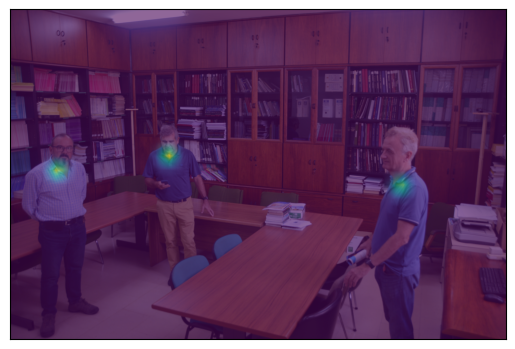

In [45]:
#############################################################
# Extraemos el mapa de confianza de la articulación cuello  #
#############################################################
import matplotlib.pyplot as plt
articulacion = 1
probMap = output[0, articulacion, :, :]
probMap = cv2.resize(probMap, (frameWidth, frameHeight))
plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
plt.imshow(probMap, alpha=0.6)
# Ocultar eje
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.savefig("openpose_confianza_cuello.jpg", dpi = 300)


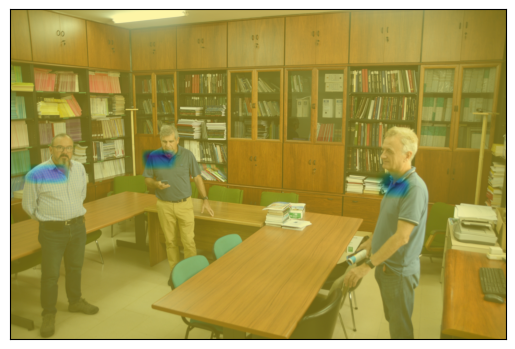

In [46]:
#############################################################
# Extraemos el mapa PAF del cuello a hombro derecho         #
#############################################################
pafA = output[0, mapIdx[0][0], :, :]
pafA = cv2.resize(pafA, (frameWidth, frameHeight))
plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
plt.imshow(pafA, alpha=0.4)
# Ocultar eje
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.savefig("openpose_paf_cuello_hombro_derecho.jpg", dpi = 300)

In [47]:
#############################################################
# Extraemos los puntos de los mapas de confianza            #
#############################################################
# Extraer los keypoints de las articulaciones
detected_keypoints = []
keypoints_list = np.zeros((0,3))
keypoint_id = 0
threshold = 0.1

for part in range(nPoints):
    probMap = output[0,part,:,:]
    # Tenemos que redimensionar los mapas de confianza de la
    # salida de la red a las dimensiones de la imagen de entrada
    probMap = cv2.resize(probMap, (image1.shape[1], image1.shape[0]))
    keypoints = getKeypoints(probMap, threshold)
    print("Keypoints - {} : {}".format(keypointsMapping[part], keypoints))
    keypoints_with_id = []
    for i in range(len(keypoints)):
        keypoints_with_id.append(keypoints[i] + (keypoint_id,))
        keypoints_list = np.vstack([keypoints_list, keypoints[i]])
        keypoint_id += 1
    detected_keypoints.append(keypoints_with_id)

# Visualizar los puntos detectados
frameClone = image1.copy()
for i in range(nPoints):
    for j in range(len(detected_keypoints[i])):
        color = [0, 0, 255]
        cv2.circle(frameClone, detected_keypoints[i][j][0:2], 20, color, -1, cv2.LINE_AA)
cv2.imwrite('openpose_puntos_esqueleto.jpg', frameClone)

Keypoints - Nose : [(4427, 1782, np.float32(0.7916857)), (644, 1696, np.float32(0.90177405)), (1932, 1609, np.float32(0.7838331))]
Keypoints - Neck : [(4769, 2130, np.float32(0.7760762)), (559, 1956, np.float32(0.90792936)), (1933, 1782, np.float32(0.9638652))]
Keypoints - R-Sho : [(4598, 2130, np.float32(0.700364)), (301, 1957, np.float32(0.7124471)), (1760, 1782, np.float32(0.82869834))]
Keypoints - R-Elb : [(4427, 2739, np.float32(0.13588218)), (214, 2390, np.float32(0.7906649)), (1675, 2128, np.float32(0.77704316))]
Keypoints - R-Wr : [(4339, 2911, np.float32(0.23348866)), (387, 2564, np.float32(0.5509656)), (1761, 2130, np.float32(0.93247086))]
Keypoints - L-Sho : [(4855, 2131, np.float32(0.7380233)), (816, 1955, np.float32(0.8684021)), (2105, 1782, np.float32(0.8936984))]
Keypoints - L-Elb : [(4684, 2739, np.float32(0.90125304)), (816, 2218, np.float32(0.39712927)), (2276, 2043, np.float32(0.8571151))]
Keypoints - L-Wr : [(4255, 3087, np.float32(0.79497087)), (816, 2477, np.float

True

In [48]:
#############################################################
# En este paso realizamos la asociación de los puntos de    #
# los esqueletos teniendo en cuenta los PAFs                #
#############################################################
valid_pairs, invalid_pairs = getValidPairs(output)
personwiseKeypoints = getPersonwiseKeypoints(valid_pairs, invalid_pairs)

# Unimos los puntos de las articulaciones de cada persona detectada
for i in range(17):
    for n in range(len(personwiseKeypoints)):
        index = personwiseKeypoints[n][np.array(POSE_PAIRS[i])]
        if -1 in index:
            continue
        B = np.int32(keypoints_list[index.astype(int), 0])
        A = np.int32(keypoints_list[index.astype(int), 1])
        color = [0, 255, 0]
        cv2.line(frameClone, (B[0], A[0]), (B[1], A[1]), color, 25, cv2.LINE_AA)

cv2.imwrite('open_pose_resultado_final.jpg', frameClone)

True

In [49]:
!ls

DSC_0154.JPG				open_pose_resultado_final.jpg
openpose_confianza_cuello.jpg		pose_deploy_linevec.prototxt
openpose_paf_cuello_hombro_derecho.jpg	pose_iter_440000.caffemodel
openpose_puntos_esqueleto.jpg		sample_data


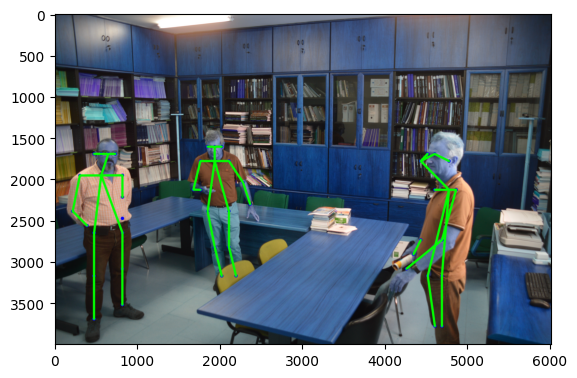

In [50]:
import matplotlib.pyplot as plt
path_im = "open_pose_resultado_final.jpg"
img = cv2.imread(path_im)
plt.imshow(img)

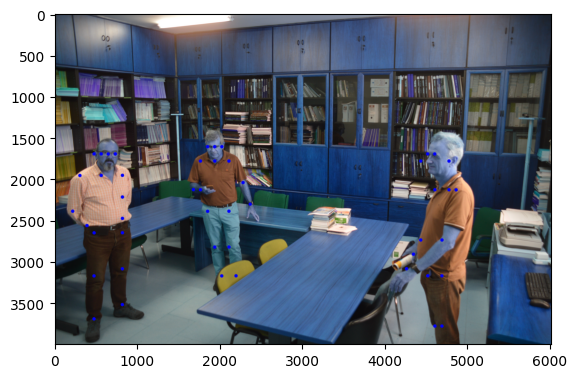

In [51]:
path_im2 = "openpose_puntos_esqueleto.jpg"
img2 = cv2.imread(path_im2)
plt.imshow(img2)